# Workshop: Can We Trust This Connectivity Analysis?

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

A collaborator (or an LLM) gave us this notebook to answer the following scientific question:

**What is the probability that one excitatory neuron connects to another as a function of soma–soma distance?**

The notebook runs without errors and produces a reasonable-looking figure.

**Can we trust the result?**

Rather than assuming the code is correct—or incorrect—we'll build evidence by reading the code, visualizing intermediate results, testing simple cases, and comparing against known expectations.

</div>

In [ ]:
# HOW TO USE (for now): Run the code with all bugs on, then perform each test below, 
# and toggle off the corresponding bug to automatically fix the code and move 
# to the next bug. In practice, students will implement these solutions. 

BUG_0 = True #Using untransformed soma coordinates, not converted to um 
BUG_1 = True #Using soma depth only, not euclidean distance 
BUG_2 = True #Wrong denominator in our probability 


In [ ]:
#Ignore
##############################################
BUGGY = False #Set all implemented BUG to True
if BUGGY: 
    BUG_0 = True
    BUG_1 = True
    BUG_2 = True

##############################################
FUTURE_BUGS = False #These are other bugs we could add in

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Analysis code we received

Run the notebook below to generate the final result.

At first glance, does the figure look plausible?

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.ipc as ipc
import matplotlib.pyplot as plt

DATA_DIR = Path("/root/capsule/data/v1dd_1196")
MAT = 1196
BIN_WIDTH_UM = 25.0
MAX_DISTANCE_UM = 900.0
MIN_PAIRS_PER_BIN = 200

### Functions

In [ ]:
def read_feather(path, columns=None):
    """Read a Feather/Arrow IPC file."""
    with open(path, "rb") as fh:
        table = ipc.open_file(fh).read_all()
    if columns is not None:
        table = table.select(columns)
    return table.to_pandas()


def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.full_like(k, np.nan), where=n > 0)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z / denom) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return np.clip(center - half, 0, 1), np.clip(center + half, 0, 1)


def get_soma_positions(cell_df, position_columns):
    """Return soma coordinates for each root ID."""

    if BUG_0:
        #BUG didn't convert nm --> um
        positions = (
            cell_df
            .set_index("pt_root_id")[position_columns]
            .to_numpy(dtype=float)
        )
    else:
        positions = (
            cell_df
            .set_index("pt_root_id")[position_columns]
            .to_numpy(dtype=float)
        ) / 1000.0
    
    return positions, position_columns


def distance_from_one_soma(pre_position, post_positions):
    """Calculate the distance from one soma to every candidate postsynaptic soma."""

    if BUG_1:
        #BUG this is using only the y coordinate (cortical depth) difference, rather than euclidean distance 
        return np.abs(post_positions[:, 1] - pre_position[1]) 
    else:
        return np.linalg.norm(post_positions - pre_position, axis=1)


def unique_connected_pairs(synapses, pre_ids, post_ids):
    """Find unique connected non-self pre/post pairs in the eligible pools."""

    if FUTURE_BUGS:
        #BUG does not remove self pairs
        eligible = (
            synapses["pre_pt_root_id"].isin(pre_ids)
            & synapses["post_pt_root_id"].isin(post_ids)
        )
    else:
        eligible = (
            synapses["pre_pt_root_id"].isin(pre_ids)
            & synapses["post_pt_root_id"].isin(post_ids)
            & (
                synapses["pre_pt_root_id"]
                != synapses["post_pt_root_id"]
            )
        )

    return (
        synapses.loc[
            eligible,
            ["pre_pt_root_id", "post_pt_root_id"],
        ]
        .drop_duplicates()
    )


def count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=25.0,
    max_distance_um=900.0,
):
    """Count eligible and connected ordered pairs in distance bins."""
    edges = np.arange(0, max_distance_um + bin_width_um, bin_width_um)
    n_bins = len(edges) - 1
    total_counts = np.zeros(n_bins, dtype=int)
    connected_counts = np.zeros(n_bins, dtype=int)

    post_id_to_row = {root_id: i for i, root_id in enumerate(post_ids)}
    connected_by_pre = {
        pre_id: np.array(
            [post_id_to_row[p] for p in group["post_pt_root_id"] if p in post_id_to_row],
            dtype=int,
        )
        for pre_id, group in connected_pairs.groupby("pre_pt_root_id")
    }

    for i, pre_id in enumerate(pre_ids):
        distances = distance_from_one_soma(pre_positions[i], post_positions)

        #BUG not removing self pairs
        if not FUTURE_BUGS:
            self_row = post_id_to_row.get(pre_id)
            if self_row is not None:
                distances[self_row] = np.nan

        valid = np.isfinite(distances) & (distances < max_distance_um)
        bins = np.floor(distances[valid] / bin_width_um).astype(int)
        total_counts += np.bincount(bins, minlength=n_bins)[:n_bins]

        connected_rows = connected_by_pre.get(pre_id, np.array([], dtype=int))
        connected_distances = distances[connected_rows]
        valid_connected = (
            np.isfinite(connected_distances)
            & (connected_distances < max_distance_um)
        )
        connected_bins = np.floor(
            connected_distances[valid_connected] / bin_width_um
        ).astype(int)
        connected_counts += np.bincount(
            connected_bins, minlength=n_bins
        )[:n_bins]

    return edges, total_counts, connected_counts

def connection_probability(connected_counts, total_counts):
    """Calculate connection probability and Wilson confidence intervals."""

    connected_counts = np.asarray(connected_counts)
    total_counts = np.asarray(total_counts)

    if BUG_2:
        # BUG: Uses the total number of eligible pairs across all distance bins
        # instead of only the eligible pairs in each bin.
        denominator = total_counts.sum()
        probability = connected_counts / denominator
        ci_denominator = np.full_like(connected_counts, denominator)
        ci_low, ci_high = wilson_ci(connected_counts, ci_denominator)

    else:
        # Correct: each distance bin has its own denominator.
        probability = np.divide(
            connected_counts,
            total_counts,
            out=np.full(connected_counts.shape, np.nan, dtype=float),
            where=total_counts > 0,
        )
        ci_low, ci_high = wilson_ci(connected_counts, total_counts)

    return probability, ci_low, ci_high

### Load the V1DD data

In [ ]:
cell = read_feather(DATA_DIR / f"soma_and_cell_type_{MAT}.feather")
proofread_axon_ids = np.load(DATA_DIR / f"proofread_axon_list_{MAT}.npy")
proofread_dendrite_ids = np.load(DATA_DIR / f"proofread_dendrite_list_{MAT}.npy")

synapses = read_feather(
    DATA_DIR / f"syn_df_all_to_proofread_to_all_{MAT}.feather",
    columns=["pre_pt_root_id", "post_pt_root_id"],
)

cell.shape, synapses.shape

((207455, 11), (8204497, 2))

### Extract excitatory cells

In [ ]:
if BUG_0:
    #BUG using untransformed coordinates
    soma_coord_columns = ["pt_position_x", "pt_position_y", "pt_position_z"]
else:
    soma_coord_columns = ["pt_position_trform_x", "pt_position_trform_y", "pt_position_trform_z"]

excitatory_cells = cell.loc[
    (cell["cell_type_coarse"] == "E")
    & (cell["pt_root_id"] != 0)
].copy()

excitatory_cells = (
    excitatory_cells
    .dropna(subset=soma_coord_columns)
    .drop_duplicates("pt_root_id")
)

pre_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_axon_ids)
].copy()

post_cells = excitatory_cells.loc[
    excitatory_cells["pt_root_id"].isin(proofread_dendrite_ids)
].copy()

pre_ids = pre_cells["pt_root_id"].to_numpy()
post_ids = post_cells["pt_root_id"].to_numpy()

all_positions, position_columns = get_soma_positions(excitatory_cells, soma_coord_columns)
root_to_row = {
    root_id: i
    for i, root_id in enumerate(excitatory_cells["pt_root_id"].to_numpy())
}
pre_positions = all_positions[[root_to_row[root_id] for root_id in pre_ids]]
post_positions = all_positions[[root_to_row[root_id] for root_id in post_ids]]

connected_pairs = unique_connected_pairs(synapses, pre_ids, post_ids)

### Run the analysis and make the figure

In [ ]:
edges, total_counts, connected_counts = count_pairs_by_distance(
    pre_ids,
    post_ids,
    pre_positions,
    post_positions,
    connected_pairs,
    bin_width_um=BIN_WIDTH_UM,
    max_distance_um=MAX_DISTANCE_UM,
)

probability, ci_low, ci_high = connection_probability(
    connected_counts,
    total_counts,
)

centers = (edges[:-1] + edges[1:]) / 2
results = pd.DataFrame({
    "distance_bin_center_um": centers,
    "n_pairs": total_counts,
    "n_connected": connected_counts,
    "connection_probability": probability,
    "ci95_low": ci_low,
    "ci95_high": ci_high,
})


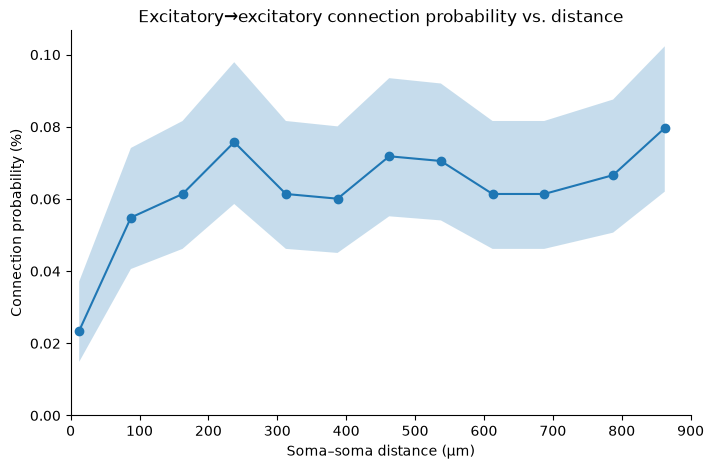

In [ ]:
reliable = total_counts >= MIN_PAIRS_PER_BIN
show = reliable & np.isfinite(probability)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(
    centers[show],
    ci_low[show] * 100,
    ci_high[show] * 100,
    alpha=0.25,
    linewidth=0,
)
ax.plot(
    centers[show],
    probability[show] * 100,
    marker="o",
)
ax.set(
    xlabel="Soma–soma distance (µm)",
    ylabel="Connection probability (%)",
    title="Excitatory→excitatory connection probability vs. distance",
    xlim=(0, MAX_DISTANCE_UM),
    ylim=(0, None),
)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Can we trust this result?

The figure looks reasonable—but appearances aren't enough.

Let's start building evidence by checking one assumption at a time. We'll begin with one of the key quantities in the analysis: the distance between neuron somata.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### Check 1: Is soma-soma distance calculated correctly?

The analysis should use the **Euclidean distance (µm)** between transformed soma coordinates.

The MICrONS volume is approximately **1.4 × 0.87 × 0.84 mm**, so distances much larger than about **1.8 mm** would be impossible.

Before reading the code:
- What range of distances do you expect?
- How could we verify that the code computes them correctly?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **visualize** the distances between one soma and all others

</div>

(BUG_0)

Given:

In [17]:
# Calculate the distance between one pre-synaptic soma, and all the post-synaptic somas
# TODO 

# Plot the distances
# TODO 

Solution:

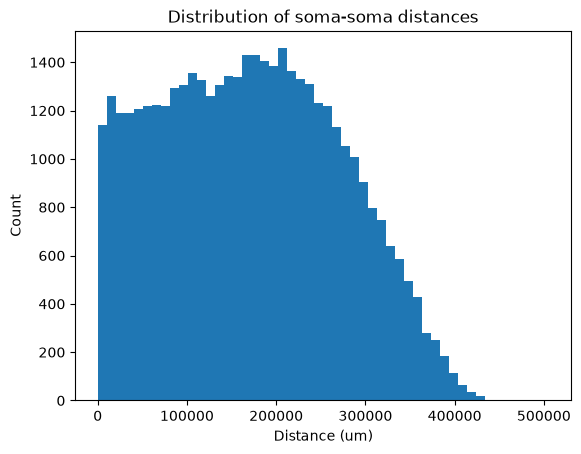

In [18]:
# Calculate the distance between one pre-synaptic soma, and all the post-synaptic somas
distances = distance_from_one_soma(pre_positions[0], post_positions)

# Plot the distances
plt.hist(distances, bins=50)
plt.xlabel("Distance (um)")
plt.ylabel("Count")
plt.title("Distribution of soma-soma distances")
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### The distances don't look plausible

Some computed distances are much larger than the maximum possible separation within the MICrONS volume.

Before changing any code, let's investigate.

Possible explanations include:
- The soma coordinates are incorrect.
- The coordinates are in a different coordinate system.
- The units are wrong.
- The distance calculation is incorrect.

A good next step is to visualize the soma positions themselves.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **visualize** the soma coordinates
*Hint: it's helpful to view multiple angles*

</div>

(BUG_0)

Given:

In [ ]:
# Make a scatter plot of the soma coordinates used in the calculateion
# Hint: is it sufficient to only view the pre or post synaptic positions?
# Hint: y is the cortical depth axis. 

#TODO

Solution:

Text(0.5, 1.0, 'Side')

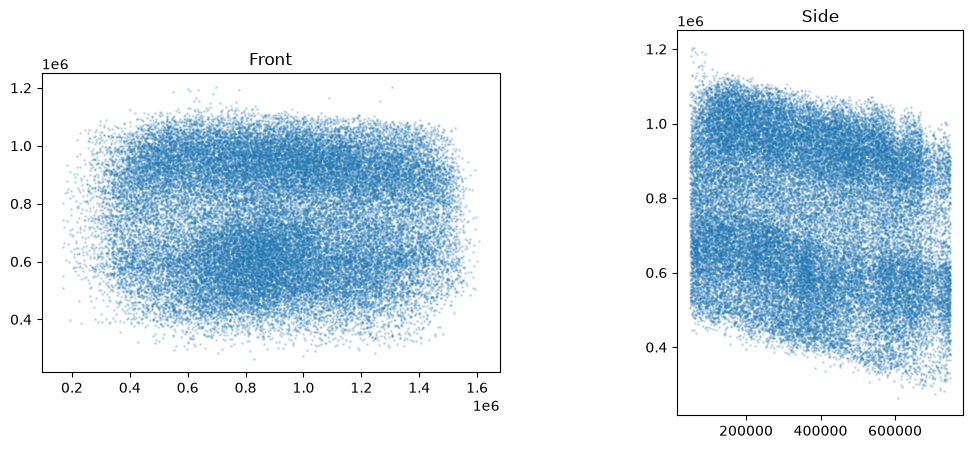

In [20]:
# Make a scatter plot of the soma coordinates used in the calculateion
# Hint: is it sufficient to only view the pre or post synaptic positions?
# Hint: y is the cortical depth axis. 

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
for ax in axes: ax.set_aspect('equal')

# view front
axes[0].scatter(post_positions[:,0], 
                post_positions[:,1],
                alpha=0.2,
                s=1
)
axes[0].set_title('Front')

# view side 
axes[1].scatter(post_positions[:,2], 
                post_positions[:,1],
                alpha=0.2,
                s=1
)
axes[1].set_title('Side')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### We found our first issue

Visualizing the soma coordinates revealed two problems:

- The coordinates are in **nanometers**, not **micrometers**.
- The coordinates have **not been transformed** into the standard reference space.

As a result, the distance calculation does **not** measure the quantity we intended.


#### **Let's fix the code to use the transformed soma coordinates in micrometers, then rerun the analysis.**


</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **Fix the code** to use the transformed soma coordinates in micrometers, then **rerun the analysis.**


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

Visualizing the real data helped us identify an issue with the soma coordinate values being used, but **it doesn't prove the distance calculation is correct.**

An easy way to build confidence is to test the function on a small **test dataset** with known expected outputs. If the function can't compute distances correctly on simple examples, we shouldn't trust it on the full dataset.

Let's build a few test cases with known soma coordinates and verify the expected distances.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Create **test data** to assess the soma distance calculation

</div>

(BUG_1)

Given:

In [ ]:
#Test two soma coordinates at different positions, but with the same cortical depth
pre_test =  np.array([  TODO  ])
post_test = np.array([[   TODO   ]])

# Determine what the distance *should* be 
expected_distance = #TODO 

# Run the existing function that calculates the distance between them 
calculated_distance = #TODO 

# Does the expected distance equal the calculated distance?
print("Calculated distance:", calculated_distance)
print("Expected distance:  ", expected_distance)


Solution

In [23]:
#Test two soma coordinates at different positions, but with the same cortical depth

pre_test = np.array([0.0, 10.0, 0.0])
post_test = np.array([[0.0, 10.0, 5.0]])

# Determine what the distance *should* be 
expected_distance = 5.0

# Run the existing function that calculates the distance between them 
calculated_distance = distance_from_one_soma(pre_test, post_test)[0]

# Does the expected distance equal the calculated distance?
print("Calculated distance:", calculated_distance)
print("Expected distance:  ", expected_distance)


Calculated distance: 0.0
Expected distance:   5.0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### The test failed

Our test data shows that the distance function does **not** return the expected values.

Before fixing the code, let's turn this check into an **assertion**. An assertion is a simple test that verifies a condition is true while the code runs. If the condition isn't met, the program immediately raises an error.

We'll first watch the assertion fail, then inspect the implementation, fix the bug, and rerun the assertion to confirm the fix.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Turn this check into an **assert** statement

</div>


Given:

In [1]:
# Add an assert statement to catch this test
#TODO 

Solution:

In [ ]:
# Add an assert statement to catch this test
assert calculated_distance == expected_distance, (
    f"Expected distance {expected_distance}, "
    f"but got {calculated_distance}."
)

AssertionError: Expected distance 5.0, but got 0.0.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **fix the bug**

Use the failing assertion to guide your debugging.

- Find and fix the bug in the distance function.
- Rerun the assertion until it passes.
- Once the test passes, continue to the next section.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Reflection

The assertion now passes—but one passing test doesn't prove the function is correct.

**What other unit tests could you write to increase your confidence in this function?**

Take a minute to brainstorm a few additional cases before moving on. 

*If you finish this part of the exercise early, write several additional tests and organize them into a unit test function that can be run with `pytest`.*

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### Check 2: Is connection probability calculated correctly?

Before reading the code, clarify the quantity we want to calculate within each soma-distance bin:

$$
P(\text{connection} \mid \text{distance bin})
= 
\frac{???}{???}
$$

* What should be counted in the numerator?
* What should be counted in the denominator?
* Which neuron pairs should be considered eligible?

Then brainstorm ways to test whether the code actually computes this quantity.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Create another **test case**, then **visually inspect** the probability function

</div>

(BUG_2)

Given:

In [28]:
# create test data for two depth bins where the number of 
# connected and eligible pairs is different but the proportions
# are the same across the bins. 
#TODO 

# Determine what the probabilities *should* be 
#TODO

# Run the existing function to calculate the probability 
# of connectivity across the depth bins
#TODO 

# Write an assertion that checks if the expectation is met 
#TODO 

Solution:

In [29]:
# create test data for two depth bins where the number of 
# connected and eligible pairs is different but the proportions
# are the same across the bins. 

connected_counts = np.array([1, 10])
total_counts = np.array([10, 100])

# Determine what the probabilities *should* be 
expected_probability = [0.1, 0.1]

# Run the existing function to calculate the probability 
# of connectivity across the depth bins
probability, ci_low, ci_high = connection_probability(
    connected_counts, 
    total_counts,
)

# Write an assertion that checks if the expectation is met 
assert np.allclose(probability, expected_probability), (
    f"Expected probabilities {expected_probability}, but got {probability}."
)

AssertionError: Expected probabilities [0.1, 0.1], but got [0.00909091 0.09090909].

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #fff9e0;">

### The test failed

The result from our test data does not match the expected connection probability, so the analysis is not calculating the quantity correctly.



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: Go back to the probability function and inspect how it computes:

* the number of connected pairs in each distance bin
* the total number of eligible pairs in each distance bin

Can you **identify the problem from the code?** If not, **design another small test** that isolates the numerator or denominator and helps reveal what is being counted incorrectly.



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

### TODO: **fix the bug**

Use the failing assertion to guide your debugging.

- Fix the bug in the probability function.
- Rerun the assertion until it passes.
- Once the test passes, continue.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

### Another way to build confidence: Compare to peer-reviewed results

Another way to evaluate an analysis is to compare your results to independent findings from the scientific literature.

If previous studies using the same or similar datasets report comparable trends, that increases confidence that your implementation is reasonable. If your results differ substantially, that's a signal to investigate further—it may reveal a bug, a difference in methodology, or a genuinely new finding.

**If you finish this exercise early:**

* Find one or more published studies related to excitatory-to-excitatory connection probability as a function of soma distance.
* Compare their findings to your result.
* Does the comparison increase or decrease your confidence in the analysis? Why?

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Discussion

### What other assumptions would you want to test, and how could you test them?

Think beyond the bugs we found today. What assumptions does this analysis make about the data, filtering, units, neuron identities, eligible pairs, binning, or interpretation of the result?

For each assumption, identify a piece of evidence that would increase—or decrease—your confidence in the analysis.

</div>


The End

# Extra

Comparison to here: https://tutorial.microns-explorer.org/quickstart_notebooks/08-standard-transform.html


## Wrong filtering: self-pairs are included

A neuron can appear in both pools if its axon and dendrite are proofread. In that case, the eligible Cartesian product contains `(cell, cell)` unless it is explicitly removed.

In [ ]:
shared_ids = np.intersect1d(pre_ids, post_ids)
print(f"Cells present in both the pre and post pools: {len(shared_ids):,}")

self_connections = connected_pairs.loc[
    connected_pairs["pre_pt_root_id"] == connected_pairs["post_pt_root_id"]
]
print(f"Connected self-pairs retained in connected_pairs: {len(self_connections):,}")

assert len(self_connections) == 0, "Connected-pair table excludes pre_id == post_id"

### Test data with a known answer

In [ ]:
pre_test_ids = np.array([1, 2, 3])
post_test_ids = np.array([2, 3, 4])

all_test_pairs = pd.MultiIndex.from_product(
    [pre_test_ids, post_test_ids],
    names=["pre", "post"],
).to_frame(index=False)

without_self = all_test_pairs.loc[all_test_pairs["pre"] != all_test_pairs["post"]]

display(all_test_pairs)
print("All ordered pairs:             ", len(all_test_pairs))
print("Ordered pairs without self:    ", len(without_self))

assert len(all_test_pairs) == 9, "Known pair count is 9 before filtering" 
assert len(without_self) == 7, "Known pair count is 7 after filtering"